In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from matplotlib import pyplot as plt
from ISLP import confusion_table, load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

16. Using the Boston data set, fit classification models in order to predict
whether a given suburb has a crime rate above or below the median.
Explore logistic regression, LDA, naive Bayes, and KNN models using
various subsets of the predictors. Describe your findings.
Hint: You will have to create the response variable yourself, using the
variables that are contained in the Boston data set.

In [2]:
Boston = load_data('Boston')

In [3]:
Boston['crim01'] = (Boston['crim'] > Boston['crim'].median()).astype('int')
Boston['crim01'].value_counts()

crim01
0    253
1    253
Name: count, dtype: int64

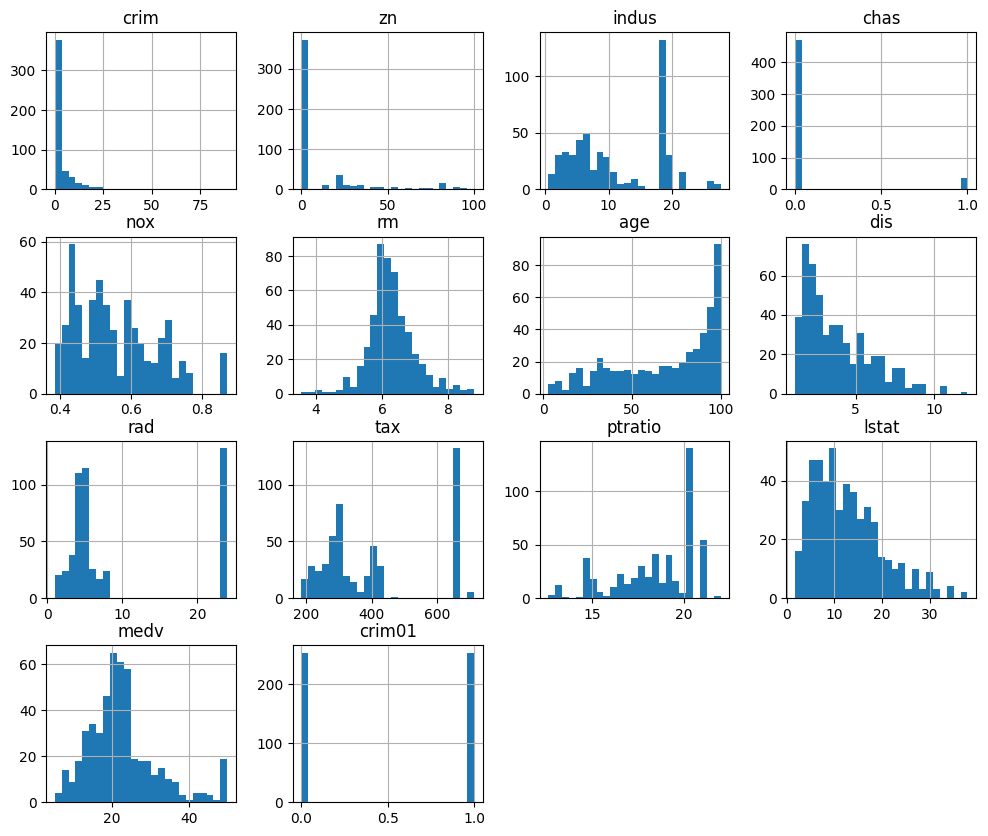

In [20]:
Boston.hist(figsize=(12,10), bins=25);

In [4]:
Boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,crim01
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305,0.409395
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445,-0.436151
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725,0.603260
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260,0.070097
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321,0.723235
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360,-0.156372
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955,0.613940
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929,-0.616342
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626,0.619786
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536,0.608741


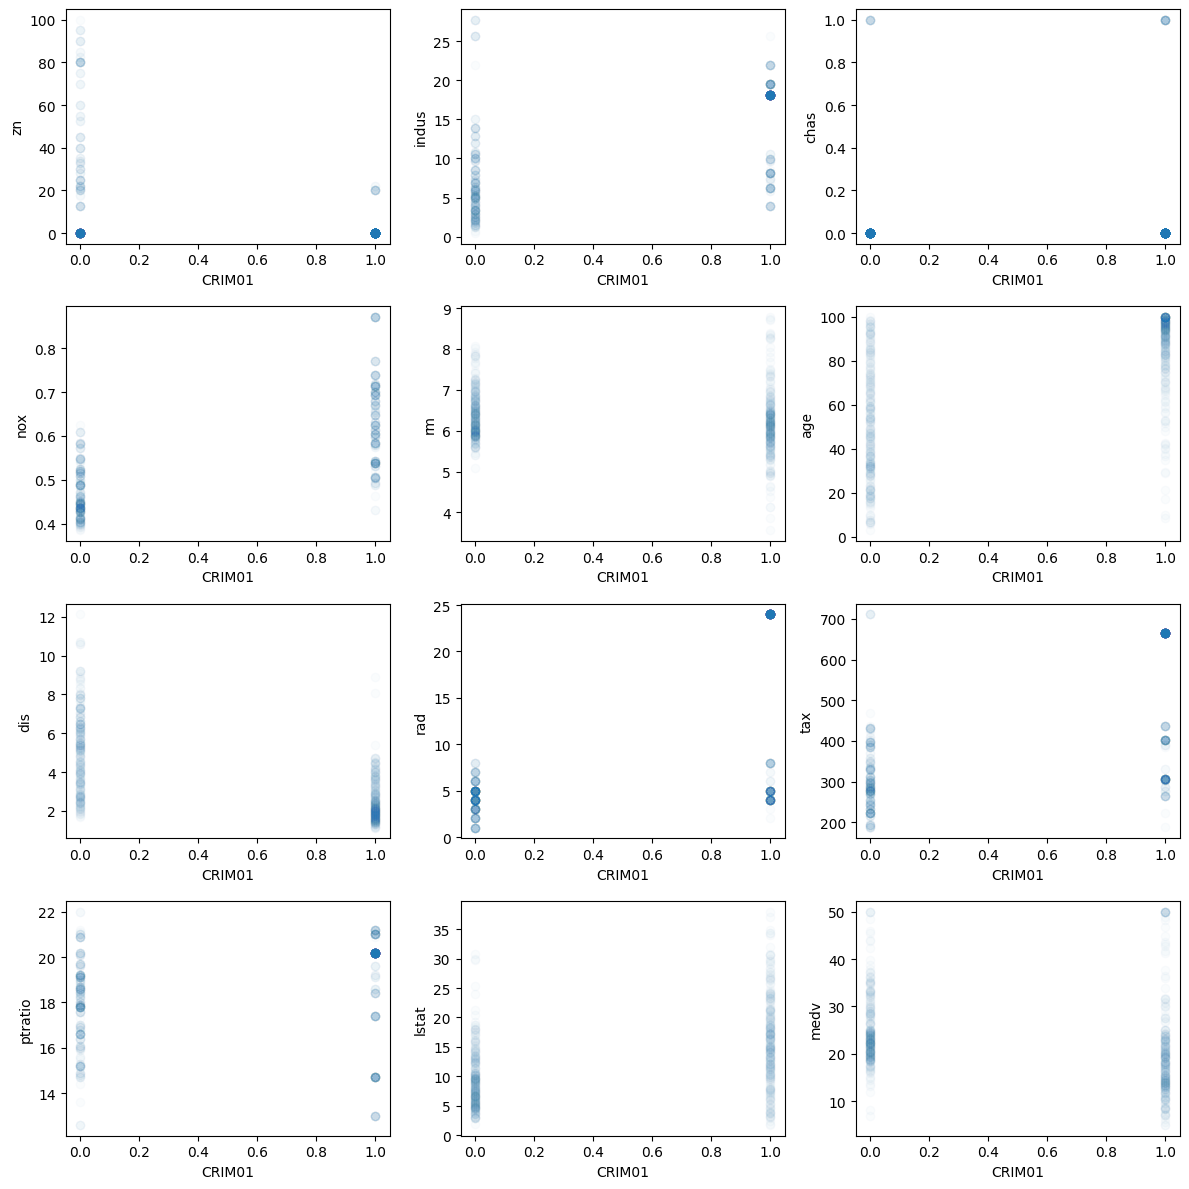

In [12]:
colunas = Boston.columns.drop(['crim','crim01'])
fig,axes = plt.subplots(nrows=4, ncols=3, figsize=(12,12))
axes_flat = axes.flatten()

for coluna, ax in zip(colunas,axes_flat):
    ax.scatter(Boston['crim01'], Boston[coluna], alpha=0.02)
    ax.set_xlabel('CRIM01')
    ax.set_ylabel(coluna)   

plt.tight_layout()
plt.show()

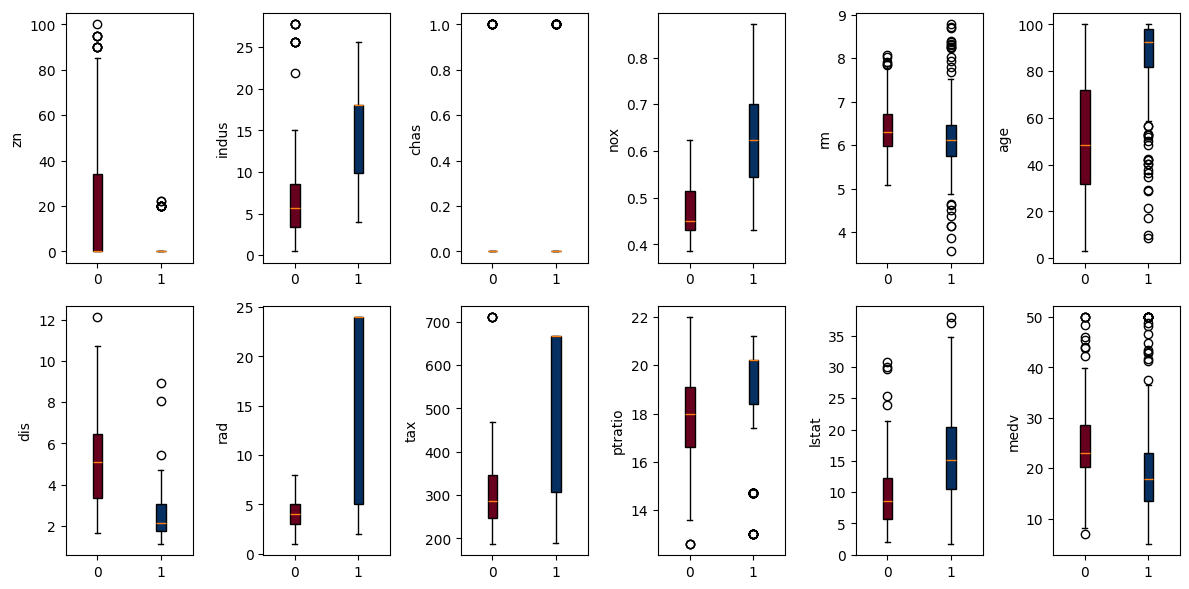

In [15]:
def plotar_boxplot(df, nome_coluna_categorica, figsize, ncolunas=4, cmap_nome='RdBu'):
    colunas = df.select_dtypes(include=[np.number]).columns.drop(nome_coluna_categorica)
    nlinhas = len(colunas)//ncolunas
    if (len(colunas)%ncolunas) > 0:
        nlinhas += 1
    categorias = df[nome_coluna_categorica].unique()
    ncategorias = len(categorias)
    cmap = plt.get_cmap(cmap_nome)
    cores = [cmap(i / max(1, ncategorias - 1)) for i in range(ncategorias)]

    fig, axes = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=figsize)
    axes_flat = axes.flatten()
    for coluna, ax in zip(colunas, axes_flat):
        ax.set_ylabel(coluna)
        box = ax.boxplot([df[df[nome_coluna_categorica] == cat][coluna] for cat in categorias], 
                        tick_labels=categorias, 
                        patch_artist=True);
        
        for caixa, cor in zip(box['boxes'], cores):
            caixa.set_facecolor(cor)
    plt.tight_layout()
    plt.show()

plotar_boxplot(Boston.drop(columns='crim'), 'crim01', (12,6), 6)

In [64]:
colunas_preditores = ['nox','ptratio', 'rad', 'tax', poly('indus',degree=2)]
Preditores = MS(colunas_preditores).fit_transform(Boston)
y = Boston['crim01']

Preditores_treino, Preditores_teste, y_treino, y_teste = train_test_split(Preditores, y, test_size=.2)

logistic_regression = sm.GLM(y_treino, Preditores_treino,family=sm.families.Binomial()).fit()
print(summarize(logistic_regression))
lr_matriz_confusao = confusion_table((logistic_regression.predict(Preditores_teste)>.5).astype('int'), y_teste)
lr_matriz_confusao

                             coef  std err      z  P>|z|
intercept                -27.4933    4.818 -5.707  0.000
nox                       43.4539    7.067  6.149  0.000
ptratio                    0.2598    0.108  2.403  0.016
rad                        0.8492    0.209  4.072  0.000
tax                       -0.0158    0.005 -3.196  0.001
poly(indus, degree=2)[0]  15.5220   10.264  1.512  0.130
poly(indus, degree=2)[1] -17.0778    6.895 -2.477  0.013


Truth,0,1
Predicted,,
0,40,3
1,12,47


In [65]:
def metricas_matriz_confusao(matriz_confusao):
    TP = matriz_confusao[1][1]
    TN = matriz_confusao[0][0]
    FP = matriz_confusao[1][0]
    FN = matriz_confusao[0][1]
    acuracia = (TP+TN)/(TP+TN+FP+FN)
    precisao = TP/(TP+FP)
    sensibilidade = TP/(TN+FN)
    especificidade = TN/(TN+FP)
    print(f'Acurácia: {acuracia}\nPrecisão: {precisao}\nSensibilidade: {sensibilidade}\nEspecificidade: {especificidade}')
    return acuracia, precisao, sensibilidade, especificidade

metricas_matriz_confusao(lr_matriz_confusao)

Acurácia: 0.8529411764705882
Precisão: 0.94
Sensibilidade: 0.9038461538461539
Especificidade: 0.9302325581395349


(np.float64(0.8529411764705882),
 np.float64(0.94),
 np.float64(0.9038461538461539),
 np.float64(0.9302325581395349))

In [70]:
lda = LDA()
lda.fit(Preditores_treino, y_treino)
lda_matriz_confusao = confusion_table(lda.predict(Preditores_teste), y_teste)
metricas_matriz_confusao(lda_matriz_confusao)
lda_matriz_confusao

Acurácia: 0.7549019607843137
Precisão: 0.64
Sensibilidade: 0.6153846153846154
Especificidade: 0.7142857142857143


Truth,0,1
Predicted,,
0,45,18
1,7,32


In [72]:
qda = QDA(reg_param=0.01)
qda.fit(Preditores_treino, y_treino)
qda_matriz_confusao = confusion_table(qda.predict(Preditores_teste), y_teste)
metricas_matriz_confusao(qda_matriz_confusao)
qda_matriz_confusao

Acurácia: 0.7254901960784313
Precisão: 0.48
Sensibilidade: 0.46153846153846156
Especificidade: 0.6578947368421053


Truth,0,1
Predicted,,
0,50,26
1,2,24
